In [8]:
import mmexofast as mmexo
import os.path
from pathlib import Path
import numpy as np
from DC18_classes import TestDataSet

In [9]:
test_data = TestDataSet(lc_num=4)
files=[test_data.file_w149, test_data.file_z087]

coords = '18:01:12.90 -27:25:37.2'
base_dir = Path('notebook_output')

In [10]:
fitter = mmexo.mmexofast.MMEXOFASTFitter(
    files=files, coords=coords, fit_type='binary_lens', finite_source=False, renormalize_errors=True, verbose=True, 
    output_config =mmexo.OutputConfig(**{'output_dir': base_dir, 'save_plots': True, 'save_grid_results': True}),
    log_file='notebook_output/OB140221_example_00.log')

In [11]:
fitter.run_ef_grid()

Saved EF grid plot to notebook_output/ef_grid.pdf.
Saved EF grid plot to notebook_output/ef_grid.pdf.
Saved EF grid plot to notebook_output/ef_grid.pdf.
Saved EF grid plot to notebook_output/ef_grid.pdf.
Best EF grid point: {'t_0': np.float64(2460024.2772946307), 't_eff': np.float64(9.988721231519582), 'j': 2, 'chi2': np.float64(-41716.45353407352)}
Best EF grid point: {'t_0': np.float64(2460024.2772946307), 't_eff': np.float64(9.988721231519582), 'j': 2, 'chi2': np.float64(-41716.45353407352)}
Best EF grid point: {'t_0': np.float64(2460024.2772946307), 't_eff': np.float64(9.988721231519582), 'j': 2, 'chi2': np.float64(-41716.45353407352)}
Best EF grid point: {'t_0': np.float64(2460024.2772946307), 't_eff': np.float64(9.988721231519582), 'j': 2, 'chi2': np.float64(-41716.45353407352)}


In [12]:
fitter.est_pl_params()

Estimated point-lens params: {'t_0': np.float64(2460024.2772946307), 't_E': 10.0, 'u_0': 1.0}
Estimated point-lens params: {'t_0': np.float64(2460024.2772946307), 't_E': 10.0, 'u_0': 1.0}
Estimated point-lens params: {'t_0': np.float64(2460024.2772946307), 't_E': 10.0, 'u_0': 1.0}
Estimated point-lens params: {'t_0': np.float64(2460024.2772946307), 't_E': 10.0, 'u_0': 1.0}


In [ ]:
fitter.fit_pspl()

Static PSPL: {'t_0': np.float64(2460024.1519435993), 't_E': np.float64(5.642278274849802), 'u_0': np.float64(2.221532502257016), 'chi2': np.float64(46878.61607370218)}
    sigmas:  [np.float64(0.04538050601295229), np.float64(2.8041428324274684), np.float64(1.4064229234446266), np.float64(7.743872386810031), np.float64(7.743850895412673), np.float64(2.623358861627357), np.float64(2.6233519895637714)]


In [8]:
#fitter.fit_fspl() #somthing is not right with this finite source fit

In [9]:
fitter.all_fit_results

<AllFitResults:
  'PSPL static': <FitRecord(lens=point, source=point, parallax=none, motion=none; params={t_0=2460024.1519435993, t_E=5.642278274849802, u_0=2.221532502257016}, sigmas={t_0=0.04538050601295229, t_E=2.8041428324274684, u_0=1.4064229234446266}; full=True, fixed=False, complete=True, renorm=True, n_params=3)>
>

In [10]:
fitter.fit_parallax()

Seeding u0+ from static model with pi_E = 0.
Parallax fit: {'t_0': np.float64(2460024.1288478696), 't_E': np.float64(5.614672408021653), 'u_0': np.float64(3.1046333637083263), 'pi_E_N': np.float64(-0.8017010212554379), 'pi_E_E': np.float64(0.0025784647025461883), 'chi2': np.float64(46851.21341847222)}
      sigmas: [np.float64(5.669575821913726), np.float64(16.364030197913458), np.float64(62.99015936223355), np.float64(65.39828086828253), np.float64(0.497059723172151), np.float64(19.545093278102023), np.float64(19.545091475655273), np.float64(6.619623157874338), np.float64(6.619622686363245)]
Parallax u0+: chi2=46851.21
Seeding u0- from static model with pi_E = 0.
Parallax fit: {'t_0': np.float64(2460024.1288478696), 't_E': np.float64(5.614672408021653), 'u_0': np.float64(3.1046333637083263), 'pi_E_N': np.float64(-0.8017010212554379), 'pi_E_E': np.float64(0.0025784647025461883), 'chi2': np.float64(46851.21341847222)}
      sigmas: [np.float64(5.669575821913726), np.float64(16.364030197

In [11]:
fitter.all_fit_results

<AllFitResults:
  'PSPL static': <FitRecord(lens=point, source=point, parallax=none, motion=none; params={t_0=2460024.1519435993, t_E=5.642278274849802, u_0=2.221532502257016}, sigmas={t_0=0.04538050601295229, t_E=2.8041428324274684, u_0=1.4064229234446266}; full=True, fixed=False, complete=True, renorm=True, n_params=3)>
  'PSPL par u0+': <FitRecord(lens=point, source=point, parallax=u0+, motion=none; params={t_0=2460024.1288478696, t_E=5.614672408021653, u_0=3.1046333637083263, pi_E_N=-0.8017010212554379, pi_E_E=0.0025784647025461883}, sigmas={t_0=5.669575821913726, t_E=16.364030197913458, u_0=62.99015936223355, pi_E_N=65.39828086828253, pi_E_E=0.497059723172151}; full=True, fixed=False, complete=True, renorm=True, n_params=5)>
  'PSPL par u0-': <FitRecord(lens=point, source=point, parallax=u0-, motion=none; params={t_0=2460024.1288478696, t_E=5.614672408021653, u_0=3.1046333637083263, pi_E_N=-0.8017010212554379, pi_E_E=0.0025784647025461883}, sigmas={t_0=5.669575821913726, t_E=16.36

In [ ]:
fitter.compute_residuals()

Calculating residuals relative to PSPL static


In [ ]:
fitter.run_af_grid()

Saved AF grid plot to notebook_output/ef_grid.pdf.
Best AF grid point: {'t_0': np.float64(2460017.5887943334), 't_eff': np.float64(0.75), 'j': np.float64(2.0), 'chi2': np.float64(395.76062914363797), 'dchi2_zero': np.float64(6346.918515250654), 'dchi2_flat': np.float64(4217.459866119311)}


In [ ]:
fitter.get_anomaly_lc_params()

Estimated anomaly params: {'t_0': np.float64(2460024.1519435993), 't_E': np.float64(5.642278274849802), 'u_0': np.float64(2.221532502257016), 'dmag': np.float64(-0.09309094546856045), 'dt': np.float64(1.1440299996174872), 't_pl': np.float64(2460017.586961)}


In [15]:
fitter.classify_anomaly()

Anomaly classified as anomaly_type = wide


/home/data/bl401/mmroz/mulens/MMEXOFAST/source/mmexofast/estimate_params.py:446: UserWarning: t_start 2460011.867 is at or beyond hard limit 2460012.867; returning hard limit.
  warnings.warn(
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: Us

WidePlanet
{'t_0': np.float64(2460024.1519435993), 'u_0': np.float64(2.221532502257016), 't_E': np.float64(5.642278274849802), 's': np.float64(2.9104060444752715), 'alpha': np.float64(63.05708953312577), 'rho': np.float64(0.1469728932075752), 'q': np.float64(0.0005527923726623856)}
[np.float64(2460001.4270870537), 'point_source', 2460012.86738705, 'hexadecapole', 2460014.7268860014, 'VBBL', 2460020.608989229, 'hexadecapole', 2460023.3071109983, 'point_source', np.float64(2460034.7474109945)]
WidePlanet_alt
{'t_0': np.float64(2460024.1519435993), 'u_0': np.float64(2.221532502257016), 't_E': np.float64(5.642278274849802), 's': np.float64(2.8059890725632237), 'alpha': np.float64(62.356572365420746), 'rho': np.float64(0.05069007340159687), 'q': np.float64(0.0001185154237985031)}
[np.float64(2460001.4270870537), 'point_source', 2460012.86738705, 'hexadecapole', 2460014.7268860014, 'VBBL', 2460020.608989229, 'hexadecapole', 2460023.3071109983, 'point_source', np.float64(2460034.7474109945)]


/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseUpperBinary
{'t_0': np.float64(2460024.1519435993), 'u_0': np.float64(2.221532502257016), 't_E': np.float64(5.642278274849802), 's': np.float64(0.34977505257010044), 'q': np.float64(0.0036613375189747228), 'rho': np.float64(0.04564223641820313), 'alpha': np.float64(234.6305456634909)}
[np.float64(2460001.4270870537), 'point_source', 2460012.86738705, 'hexadecapole', 2460014.7268860014, 'VBBL', 2460020.447035999, 'hexadecapole', 2460023.3071109983, 'point_source', np.float64(2460034.7474109945)]


/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


...

/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseLowerBinary
{'t_0': np.float64(2460024.1519435993), 'u_0': np.float64(2.221532502257016), 't_E': np.float64(5.642278274849802), 's': np.float64(0.3494894863043352), 'q': np.float64(0.01378289319955126), 'rho': np.float64(0.08189898548019826), 'alpha': np.float64(-102.88434454481848)}
[np.float64(2460001.4270870537), 'point_source', 2460012.86738705, 'hexadecapole', 2460014.7268860014, 'VBBL', 2460020.447035999, 'hexadecapole', 2460023.3071109983, 'point_source', np.float64(2460034.7474109945)]


/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


CloseLowerBinary_alt
{'t_0': np.float64(2460024.1519435993), 'u_0': np.float64(2.221532502257016), 't_E': np.float64(5.642278274849802), 's': np.float64(0.35036952591264353), 'q': 0.004, 'rho': 0.001, 'alpha': np.float64(-109.89409376934861)}
[np.float64(2460001.4270870537), 'point_source', 2460012.86738705, 'hexadecapole', 2460014.7268860014, 'VBBL', 2460020.447035999, 'hexadecapole', 2460023.3071109983, 'point_source', np.float64(2460034.7474109945)]


/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))


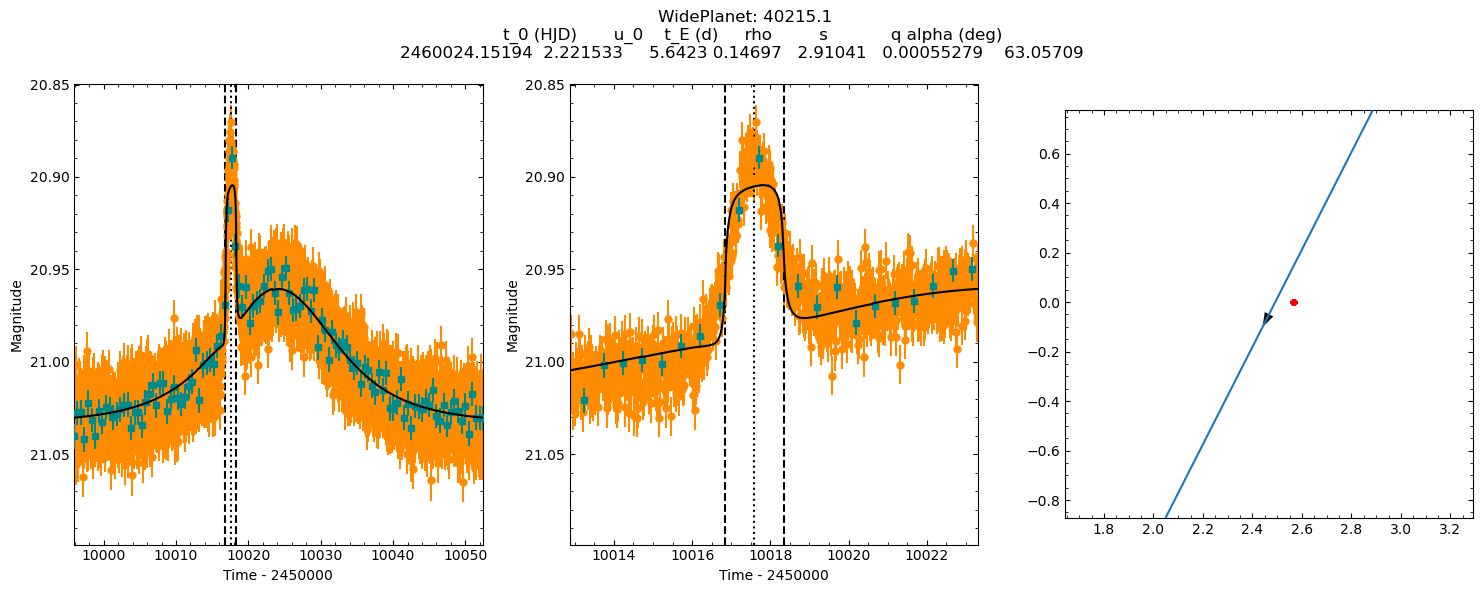

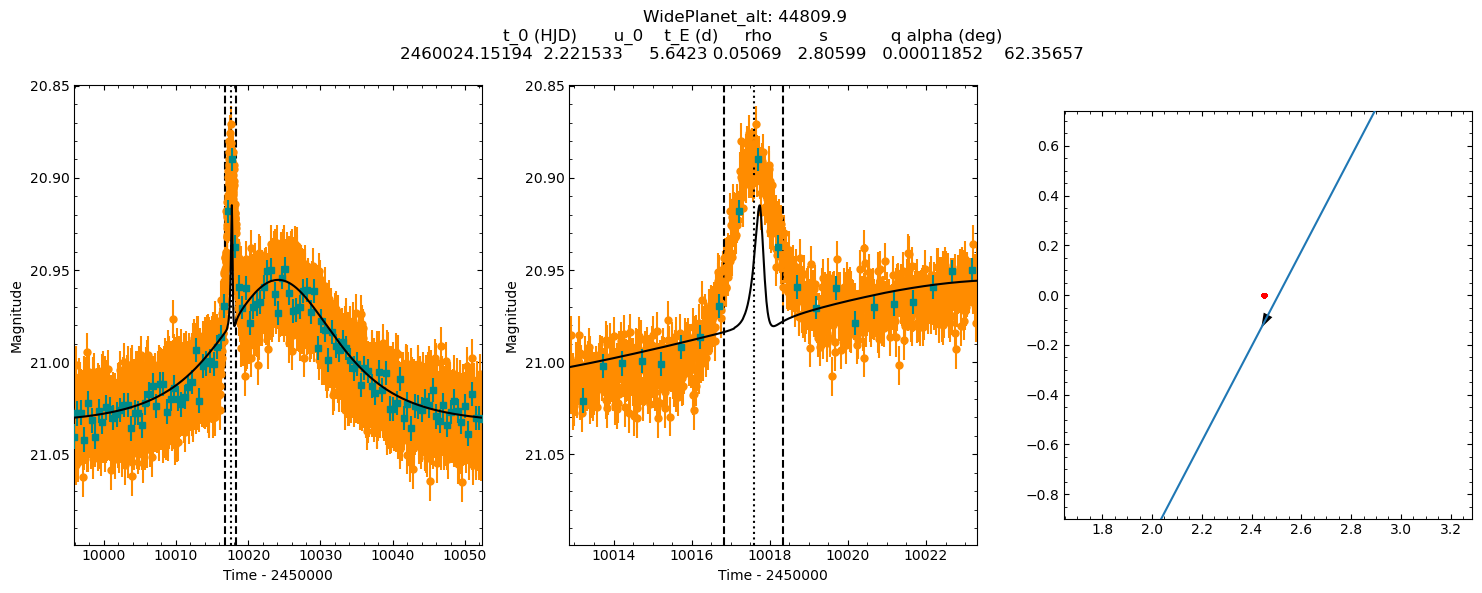

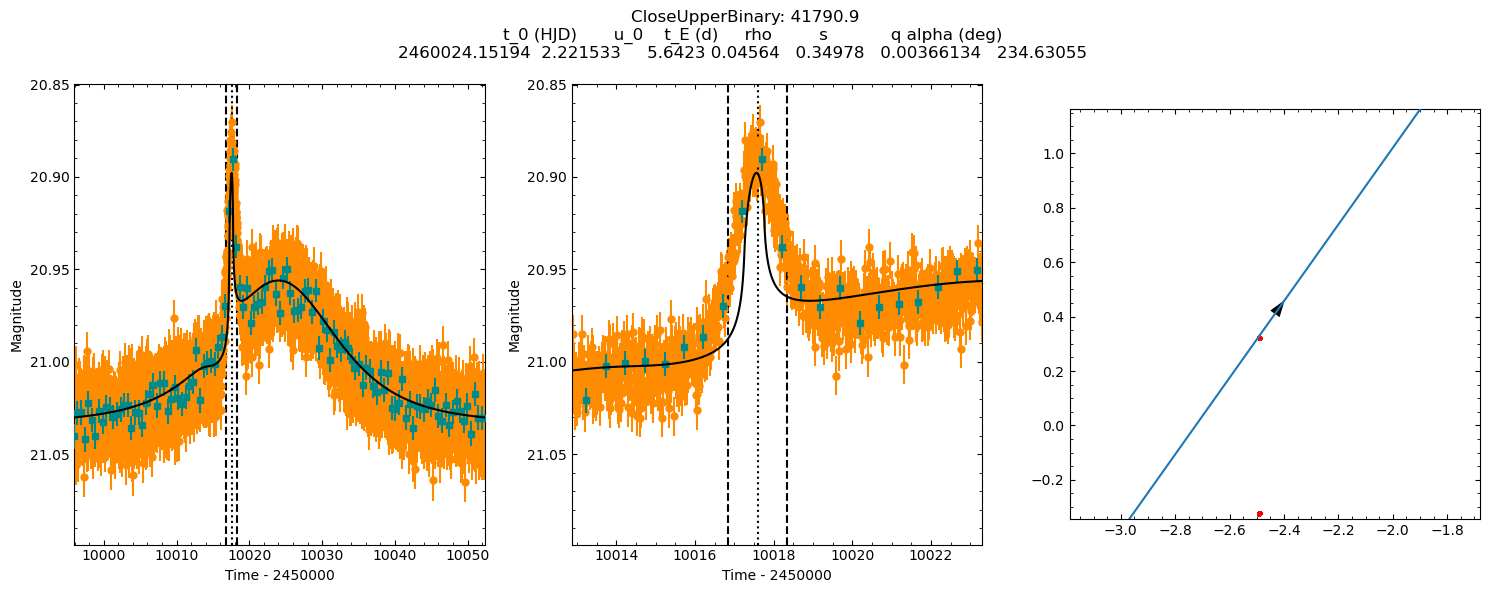

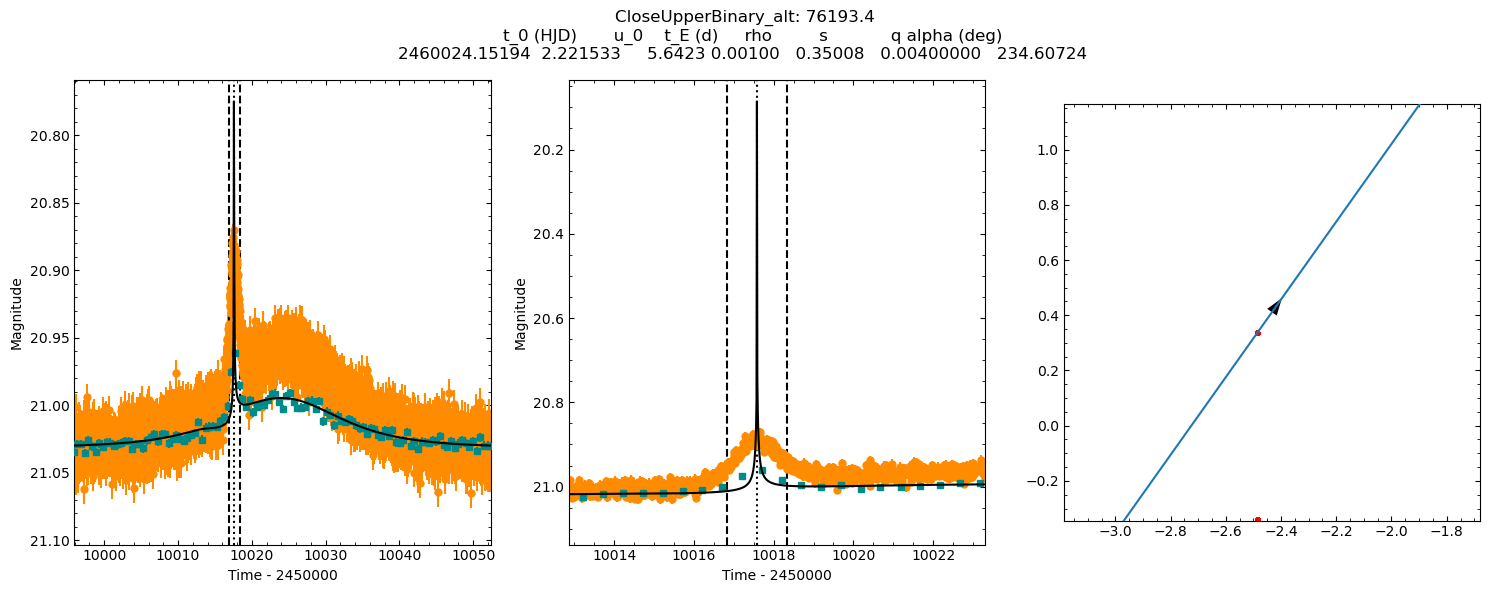

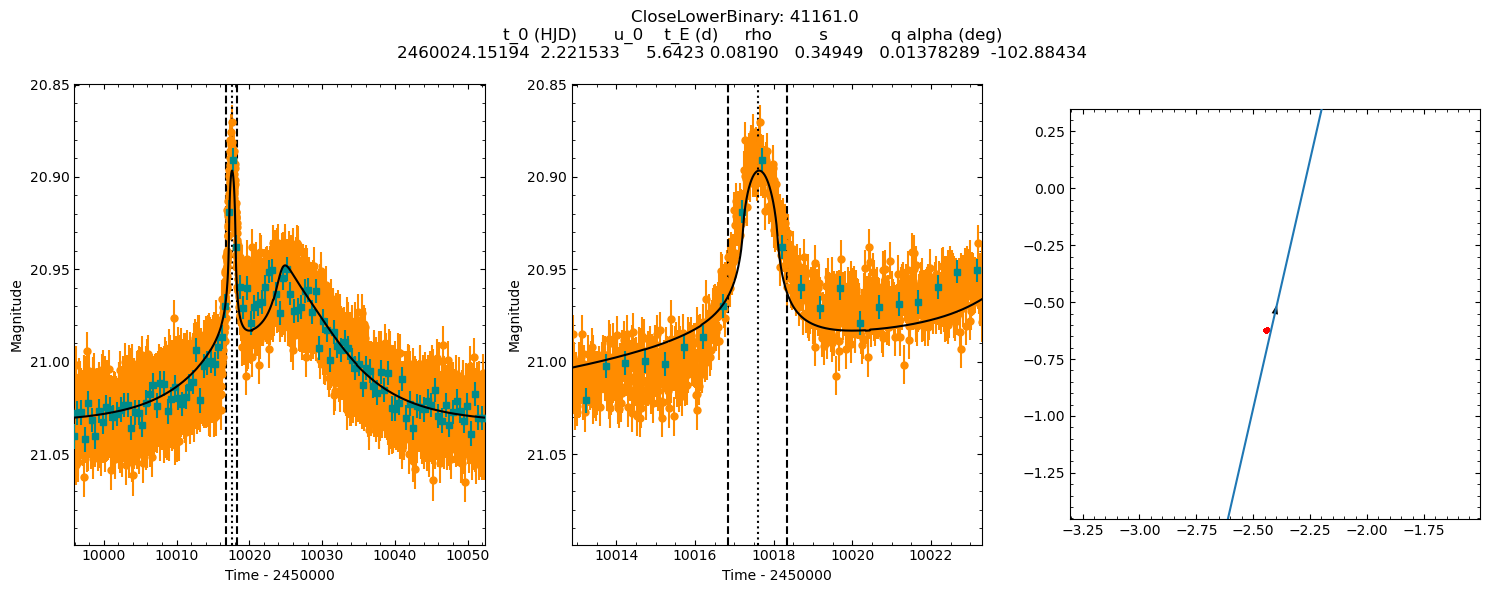

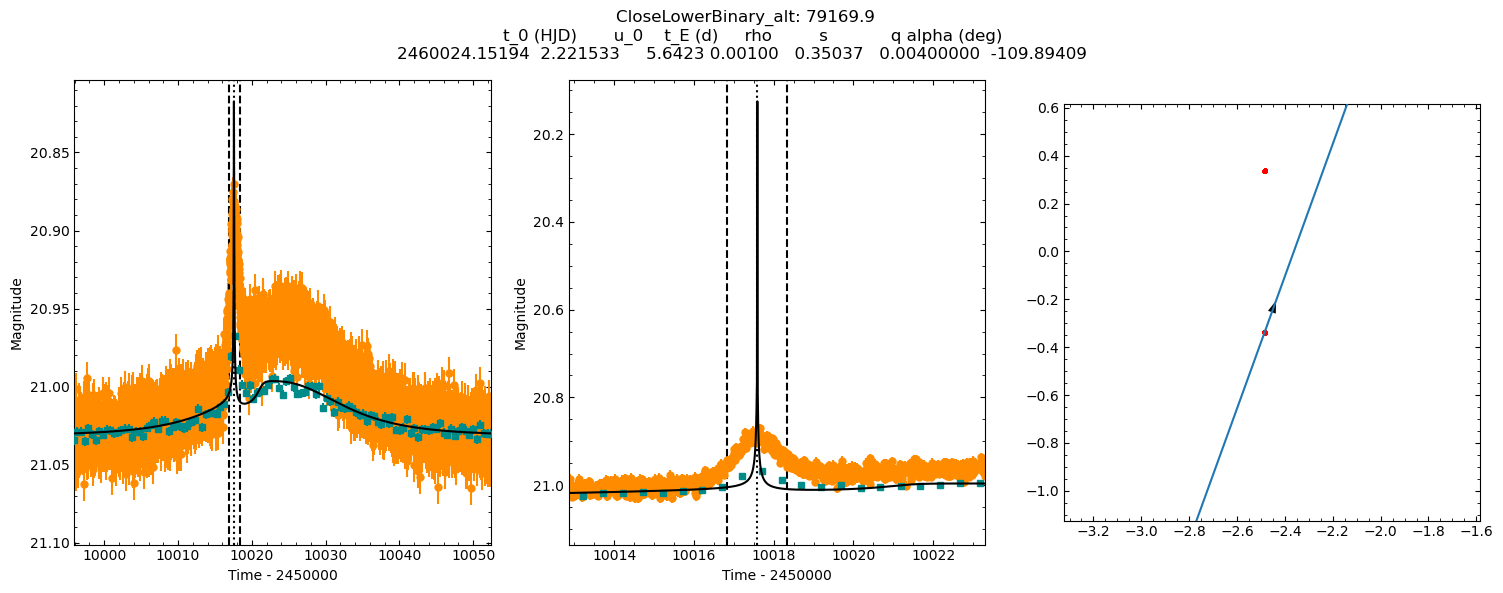

In [ ]:
fitter.est_binary_params()

In [ ]:
fitter.fit_binary_lens_models()

PL chi2: 46878.6, N_good: 39438
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is W149 but model does not have a limb-darkening coefficient for W149. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
/home/data/bl401/mmroz/mulens/MulensModel/source/MulensModel/fitdata.py:63: UserWarning: Dataset bandpass is Z087 but model does not have a limb-darkening coefficient for Z087. Assuming zero.
  warnings.warn(msg.format(self.dataset.bandpass))
WidePlanet initial chi2: 40215.1
initial sigmas: {'t_0': 1e-05, 'u_0': np.float64(0.002221532502257016), 't_E': np.float64(0.0056422782748498015), 'log_rho': 0.0001, 'log_s': 0.0001, 'log_q': 0.0001, 'alpha': 0.0001}


In [ ]:
fitter.fit_parallax()

In [ ]:
fitter.renormalize_datasets()